# Hillik: a consistent High-&ell; likelihood

[``Hillik``](#https://github.com/mtristram/hillik) is a CMB likelihood based on cross-power spectra which can accomodate spectra from different survey (Planck, SPT, ACT) within a common modelisation of the foreground residuals.\
The likelihood is a Gaussian approximation with a signal model including CMB, galactic emissions (dust), poisson noise (from unmasked point sources) and extra-galactic emissions (tSZ, CIB, kSZ, SZxCIB).\
Nuisance parameters (calibration, polar efficiency, T-E-B leakage, ...) are associated to each survey with the exact same treatment as in the original studies.

In [1]:
import MCtools
from getdist import plots, MCSamples
import warnings
warnings.filterwarnings("ignore")
DBdir = "/sps/planck/Users/tristram/Soft/Hillik/chains"
clth = read_cl( "/sps/planck/Users/tristram/Models/planck_base_planck_2018_TTTEEElowllowE.fits")
lth = arange(len(clth[0]))

## Table Of Content
* [Check original likelihood](#Check-original-likelihood)
* [Planck](#Planck)
* [SPT](#SPT)
* [ACT](#ACT)
* [TT](#TT)
* [TE](#TE)
* [EE](#EE)
* [TTTEEE](#TTTEEE)

## Check original likelihood

In [2]:
runnames1 = ['hlpTT','spt','actpol']
chains1 = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames1]
runnames2 = ['hillik_plk','hillik_spt','hillik_act']
chains2 = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames2]

hlpTT: 179521  191841  180361  177001 
spt: 173441  128641  129281  189441 
actpol: 205921  162241  251521  200001 
hillik_plk: 263583  179464  197081  196211 
hillik_spt: 822482  641454  614436  739384 
hillik_act: 859001  694859  854156  926618 


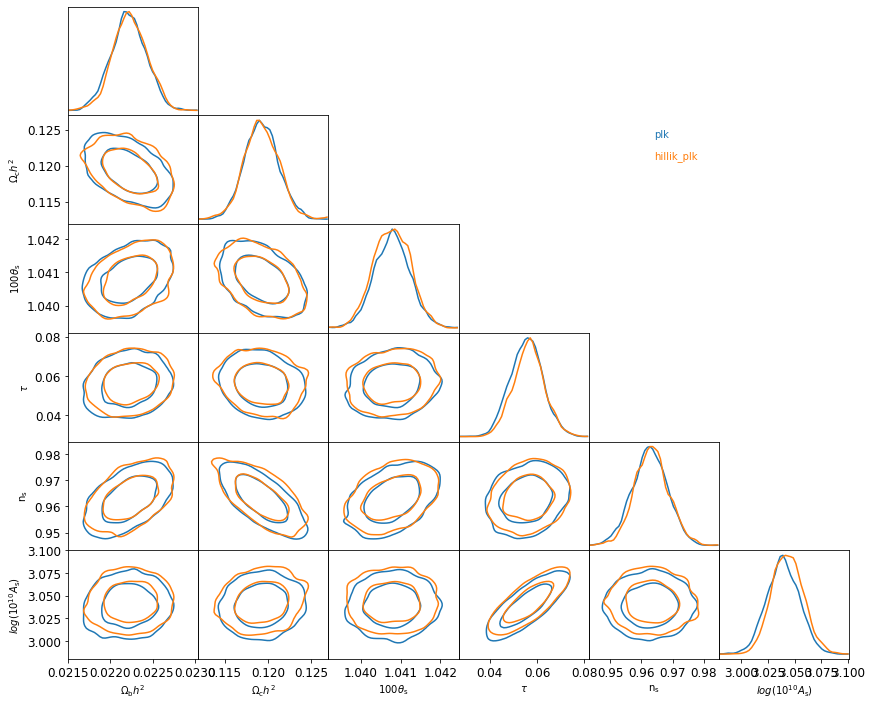

In [3]:
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( [chains1[0],chains2[0]], listpar, labels=['plk','hillik_plk'])

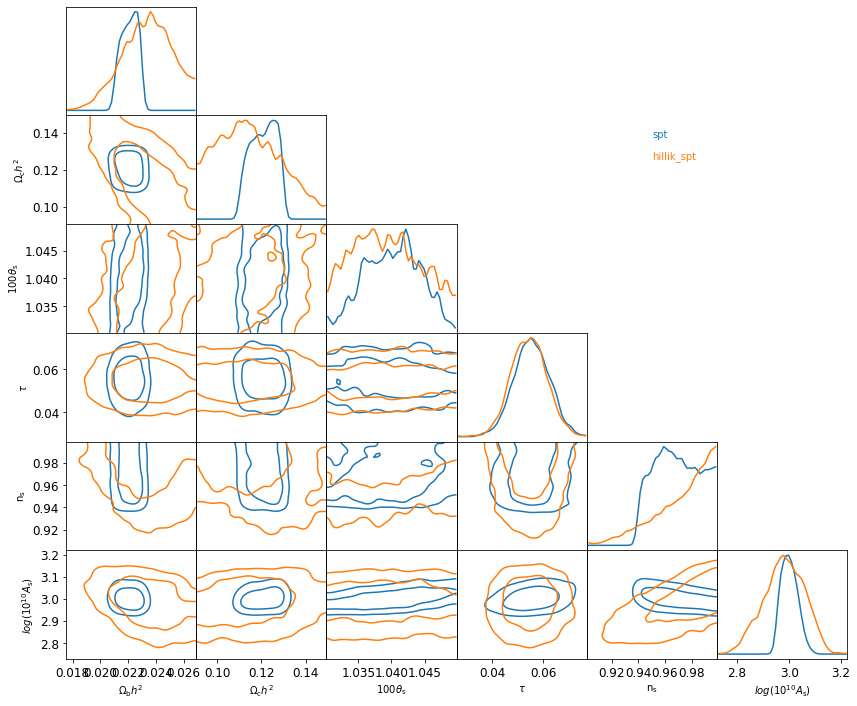

In [4]:
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( [chains1[1],chains2[1]], listpar, labels=['spt','hillik_spt'])

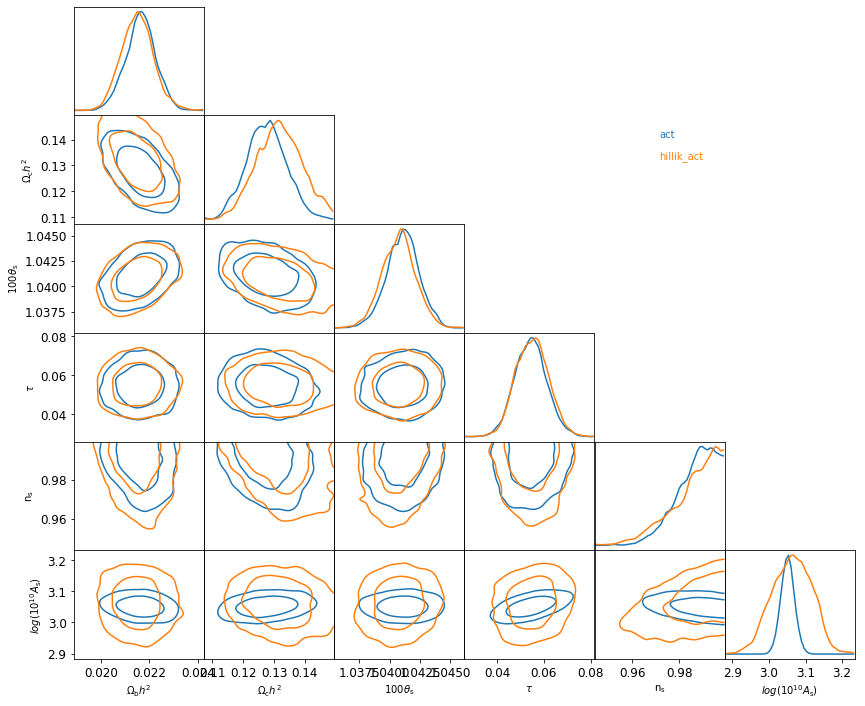

In [5]:
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( [chains1[2],chains2[2]], listpar, labels=['act','hillik_act'])

In [6]:
runnames = ['hillik_plk','hillik_spt','hillik_act']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]

hillik_plk: 263583  179464  197081  196211 
hillik_spt: 822482  641454  614436  739384 
hillik_act: 859001  694859  854156  926618 


                         hillik_plk                 hillik_spt                 hillik_act
ombh2           =  0.022234 +/- 0.000205  |   0.023465 +/- 0.001896  |   0.021488 +/- 0.000647
omch2           =  0.119191 +/- 0.002016  |   0.113240 +/- 0.015678  |   0.131661 +/- 0.007483
theta           =  1.040791 +/- 0.000468  |   1.039443 +/- 0.006353  |   1.040787 +/- 0.001417
tau             =  0.056782 +/- 0.006608  |   0.054397 +/- 0.006725  |   0.054989 +/- 0.007048
ns              =  0.963273 +/- 0.005505  |   0.979140 +/- 0.021846  |   0.988863 +/- 0.010553
logA            =  3.043065 +/- 0.014424  |   2.983801 +/- 0.080846  |   3.064330 +/- 0.054625


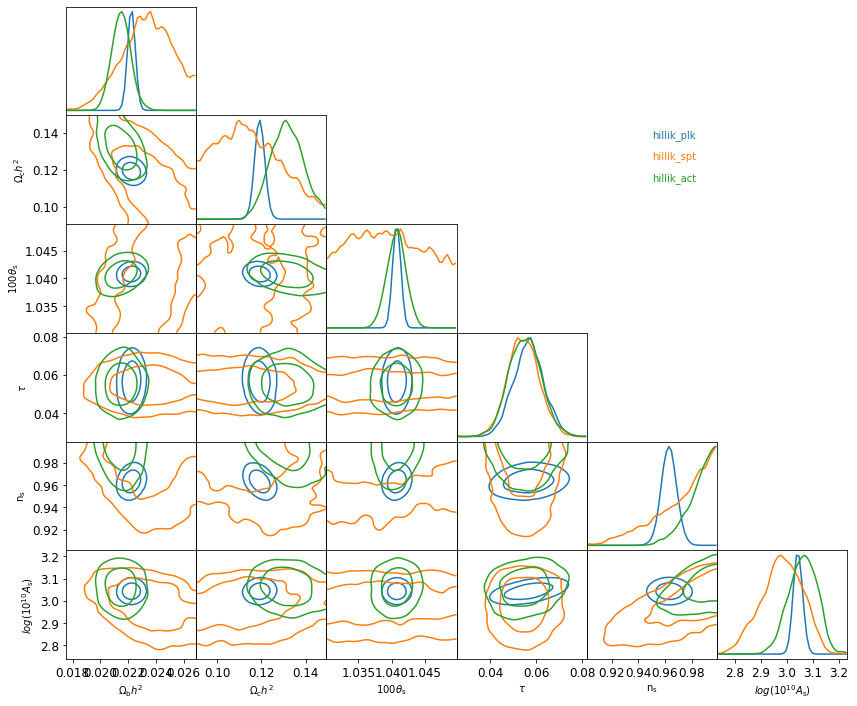

In [7]:
#cosmo
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames)
print( "%35s %26s %26s" % tuple(runnames))
for par in listpar:
    MCtools.PrintMax( chains, par)

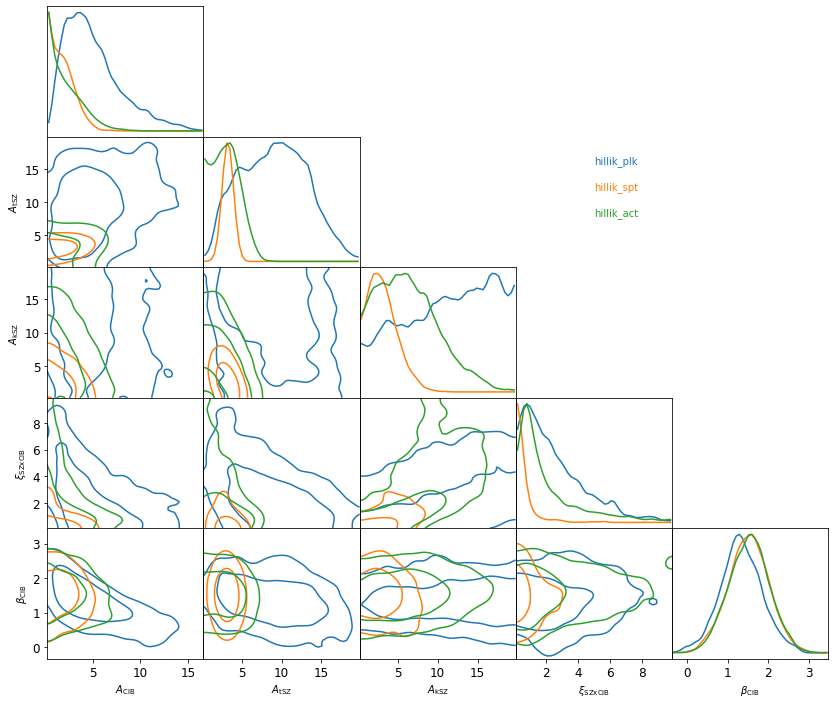

In [8]:
#extra-galactic fg
listpar = ['Acib','Atsz','Aksz','xi', 'beta_cib']
fig=MCtools.triangle( chains, listpar, labels=runnames)

# Planck

hillik_plk: 160290  232672  196615  116116 
hillik_plkTE: 143472  143200  117287  103647 
hillik_plkEE: 90161  45441  70001  128001 
hillik_plkTTTEEE: 62930  22557  67053  66670 


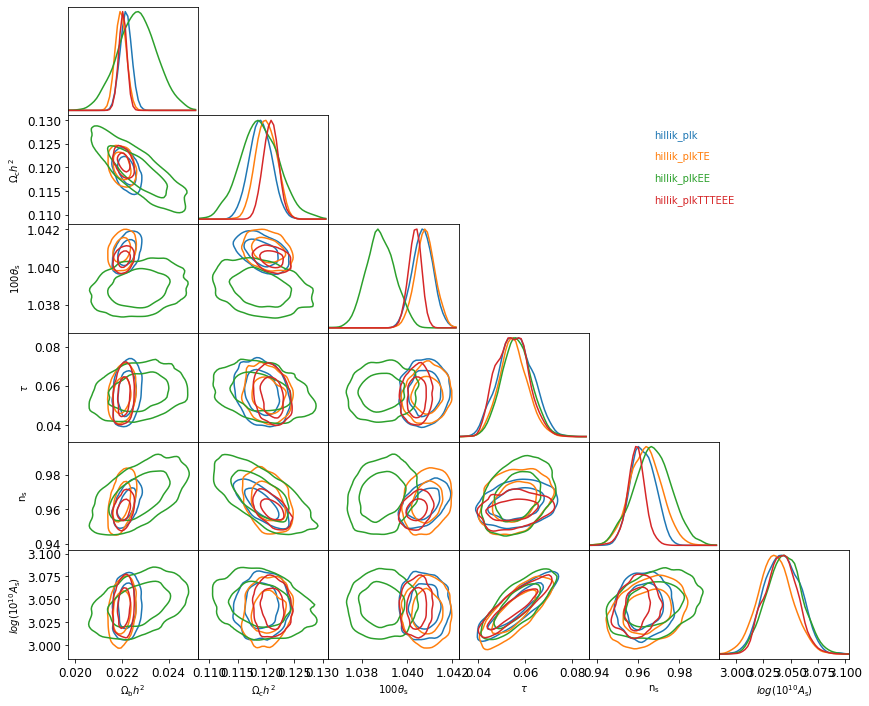

In [31]:
runnames = ['hillik_plk','hillik_plkTE','hillik_plkEE','hillik_plkTTTEEE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

# SPT

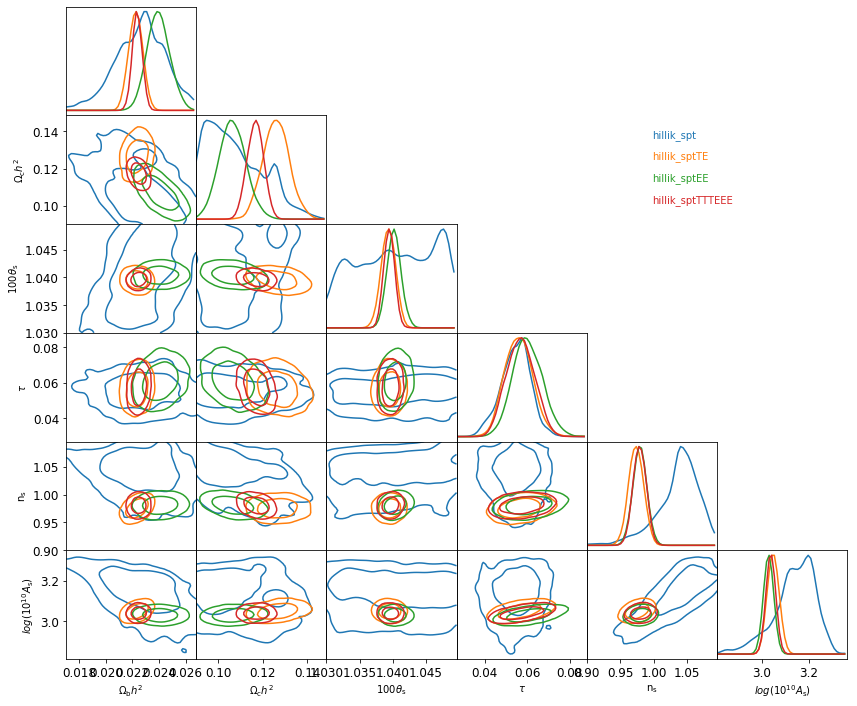

In [30]:
runnames = ['hillik_spt','hillik_sptTE','hillik_sptEE','hillik_sptTTTEEE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 720x720 with 0 Axes>

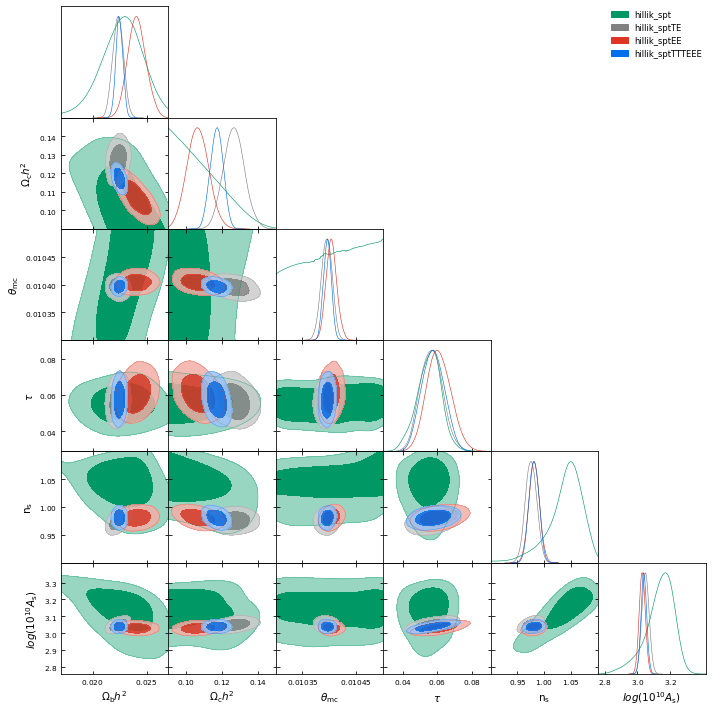

In [7]:
listpar = ['ombh2','omch2','cosmomc_theta','tau','ns','logA']
runnames = ['hillik_spt','hillik_sptTE','hillik_sptEE','hillik_sptTTTEEE']
support = {'ombh2':(0.017,0.027),'omch2':(0.09,0.15),'cosmomc_theta':(0.0103,0.0105),'tau':(0.01,0.15),'ns':(0.9,1.1),'logA':(2.6,3.5)}
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9) for run in runnames]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled = True, legend_labels = runnames,legend_loc = 'upper right')

# ACT

hillik_act: 444248  463494  490762  488775 
hillik_actTE: 376232  482221  425344  466043 
hillik_actEE: 120961  109201  120641  143521 
hillik_actTTTEEE: 479782  492355  748953  751139 


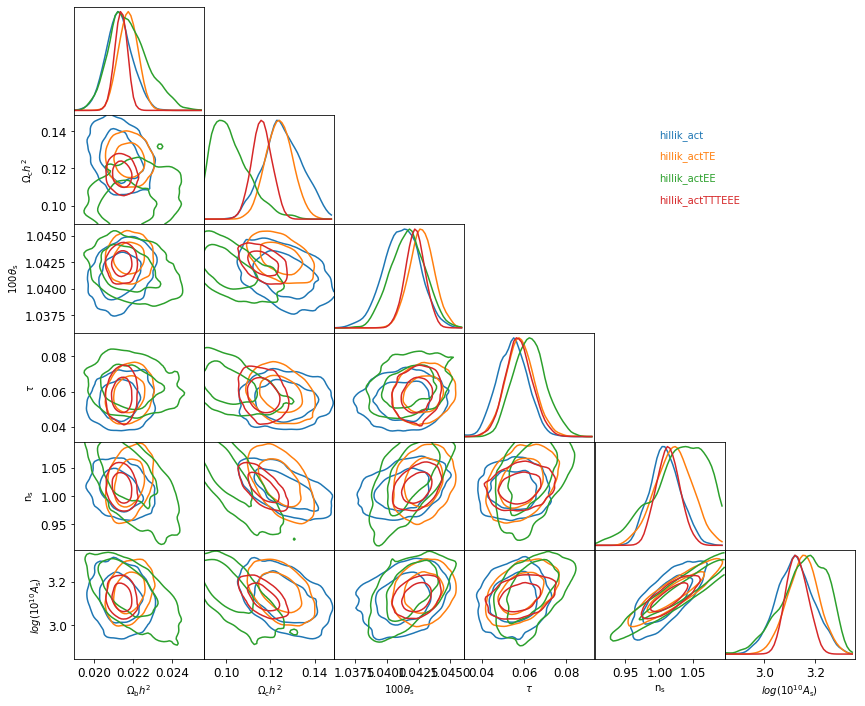

In [32]:
runnames = ['hillik_act','hillik_actTE','hillik_actEE','hillik_actTTTEEE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=20000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

hillik_act: 444248  463494  490762  488775 
hillik_actTE: 376232  482221  425344  466043 
hillik_actEE: 120961  109201  120641  143521 
hillik_actTTTEEE: 479782  492355  748953  751139 
Removed no burn in
Removed no burn in
Removed no burn in
Removed no burn in


<Figure size 720x720 with 0 Axes>

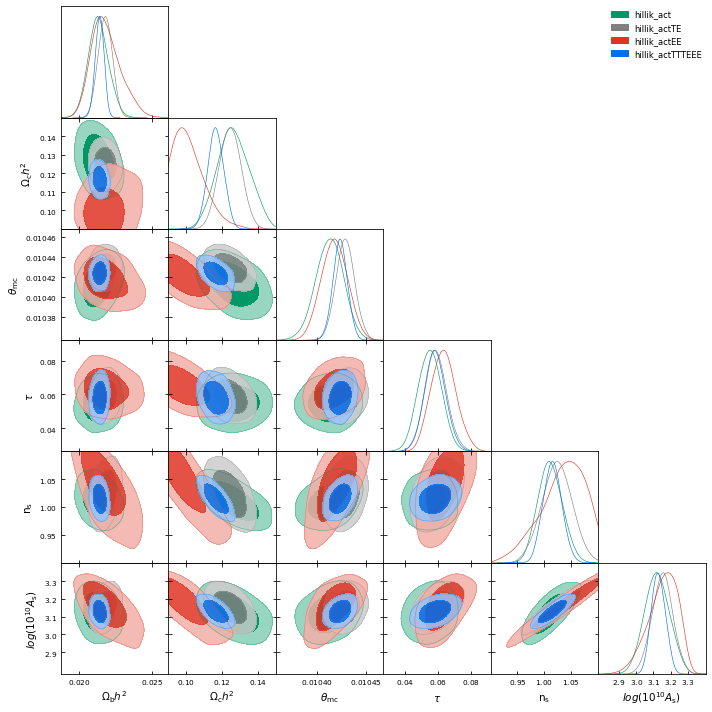

In [8]:
listpar = ['ombh2','omch2','cosmomc_theta','tau','ns','logA']
runnames = ['hillik_act','hillik_actTE','hillik_actEE','hillik_actTTTEEE']
support = {'ombh2':(0.017,0.027),'omch2':(0.09,0.15),'cosmomc_theta':(0.0103,0.0105),'tau':(0.01,0.15),'ns':(0.9,1.1),'logA':(2.6,3.5)}
labels = [MCtools.parname.get(p,p).replace('$','') for p in listpar]
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9) for run in runnames]
samples = [MCSamples( samples=[chain[p] for p in listpar], names=listpar, labels=labels, ranges=support) for chain in chains]
g = plots.getSinglePlotter(width_inch=10, ratio=1)
g.triangle_plot(samples, listpar, filled = True, legend_labels = runnames,legend_loc = 'upper right')

# TT

hillik_plk: 160290  232672  196615  116116 
hillik_act: 444248  463494  490762  488775 
hillik_spt: 119639  655663  316686  423993 
hillik_plksptact: 880813  1017840  939259  693479 


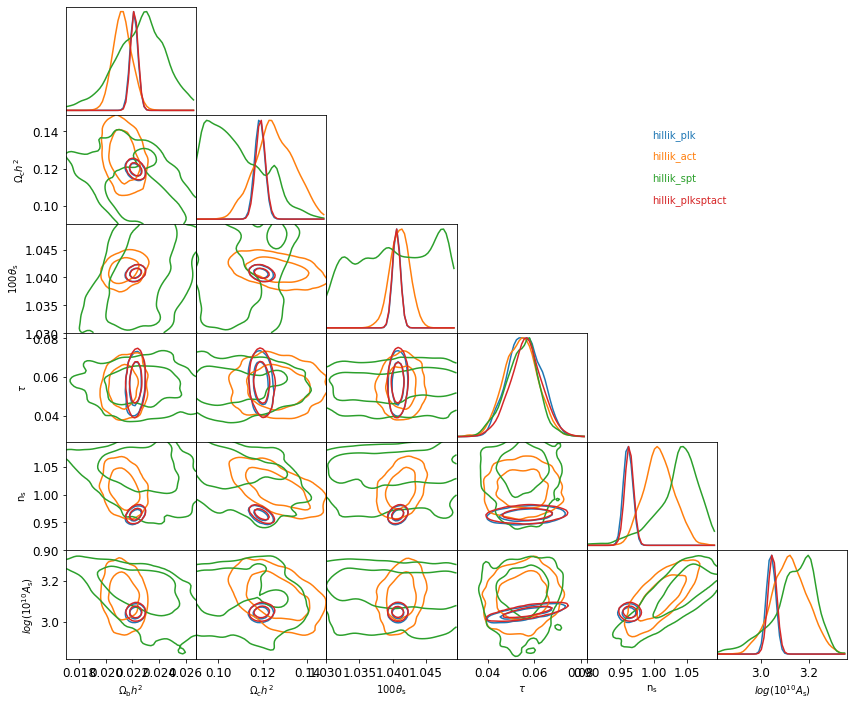

In [33]:
runnames = ['hillik_plk','hillik_act','hillik_spt','hillik_plksptact']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

# TE

hillik_plkTE: 146913  145772  120948  106152 
hillik_actTE: 376232  482221  425344  466043 
hillik_sptTE: 142721  190391  339361  228085 
hillik_plksptact_TE: 774802  666347  716726  784353 


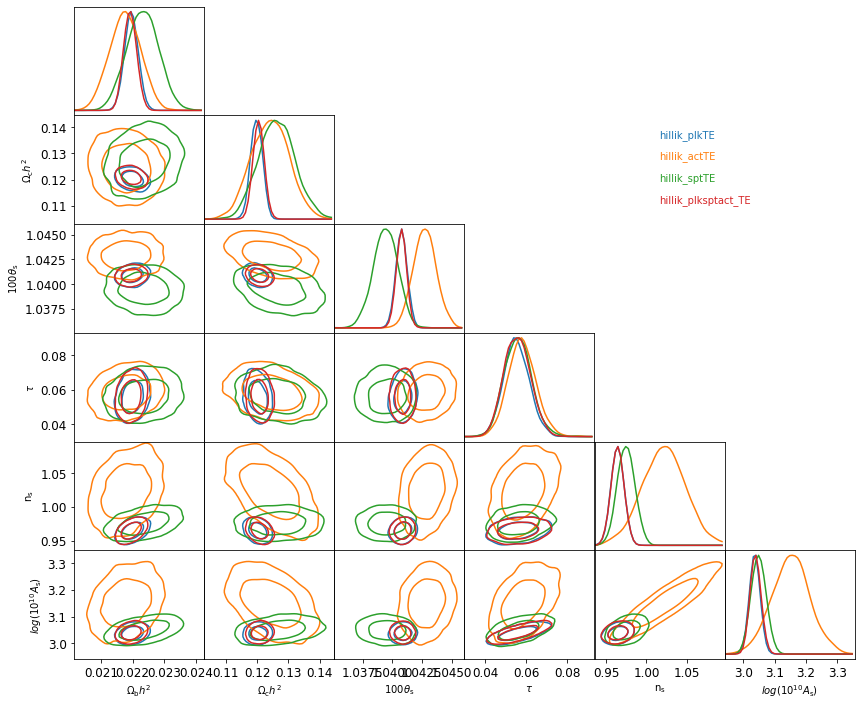

In [35]:
runnames = ['hillik_plkTE','hillik_actTE','hillik_sptTE','hillik_plksptact_TE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

# EE

hillik_plkEE: 90161  45441  70001  128001 
hillik_actEE: 120961  109201  120641  143521 
hillik_sptEE: 480801  348801  271921  238401 
hillik_plksptact_EE: 418746  964517  524601  429201 


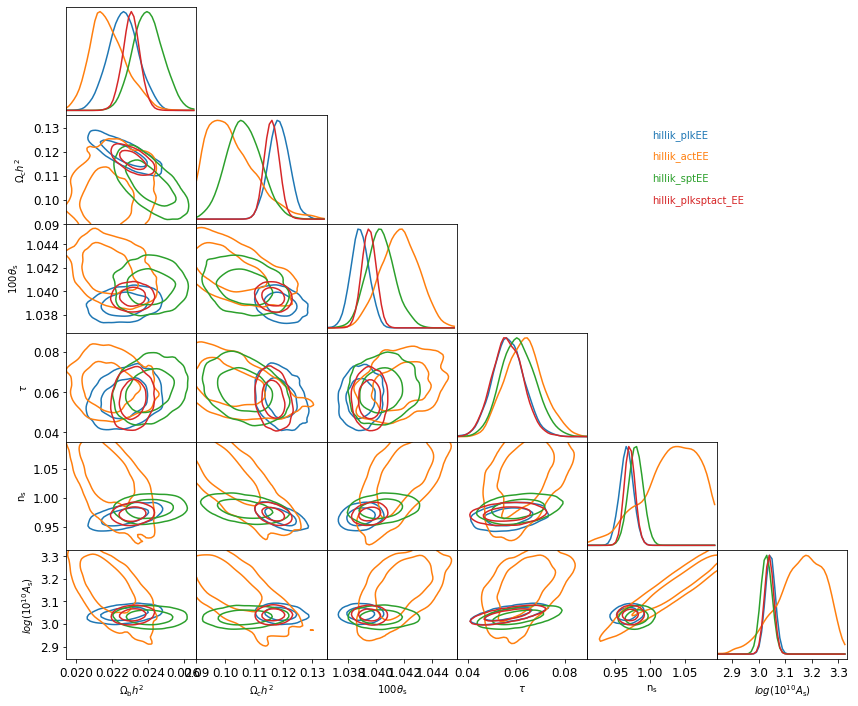

In [34]:
runnames = ['hillik_plkEE','hillik_actEE','hillik_sptEE','hillik_plksptact_EE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=0.9, nelts=10000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

# TT+TE+EE

In [2]:
runnames = ['hillik_plkTTTEEE','hillik_actTTTEEE','hillik_sptTTTEEE','hillik_plksptact_TTTEEE']
chains = [MCtools.mergeMC( "%s/%s/mcmc" % (DBdir,run), burnin=-20000, nelts=20000) for run in runnames]
listpar = ['ombh2','omch2','theta','tau','ns','logA']
fig=MCtools.triangle( chains, listpar, labels=runnames, kde=True)

hillik_plkTTTEEE: 64999  28698  70008  69538 
hillik_actTTTEEE: 1044  1096  2404  1534 
hillik_sptTTTEEE: 719  1100  1030  954 
hillik_plksptact_TTTEEE: 976849  1581072  1502556  1722640 


KeyError: 'chi2'

<Figure size 1008x864 with 0 Axes>